In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

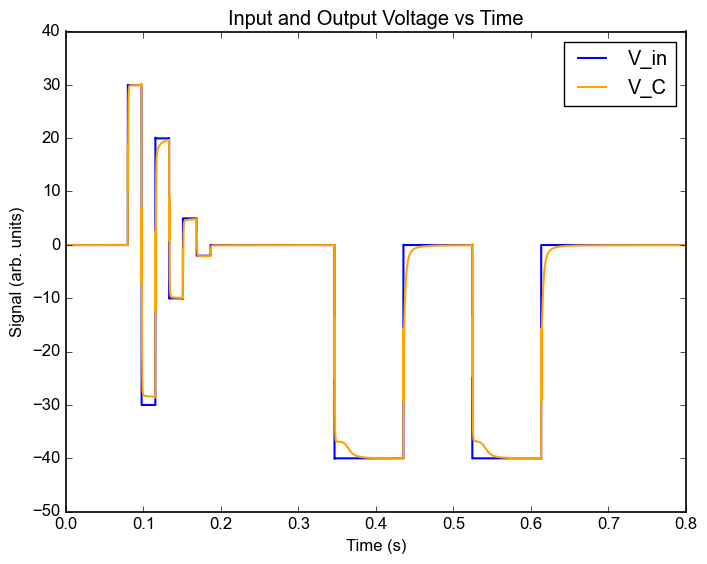

In [77]:
data1 = np.loadtxt("./Data_20262904/20262904005.dat")
data2 = np.loadtxt("./Data_20262904/20262904005.snp")

R1 = 1e6
R2 = 1e5  # Resistance in ohms
Amp = 20

t = data1[:, 0]
V_R = data1[:, 1]
main_trigger = data1[:, 2]
V_in = data1[:, 3]*(-Amp)
second_trigger = data1[:, 4]
I = data1[:, 5]

V_C = V_in - V_R/R2 *(R1 + R2)


plt.plot(t, V_in, label='V_in', lw = 1.5, color = 'blue')
# plt.plot(t, V_R*10, label='V_R', lw = 1.5, color = 'green')
plt.plot(t, V_C, label='V_C', lw = 1.5, color = 'orange')
# plt.plot(t, main_trigger, label='Main Trigger', lw = 1.5, color = 'red')
# plt.plot(t, second_trigger, label='Second Trigger', lw = 1.5, color = 'black')
plt.xlabel('Time (s)')
plt.ylabel('Signal (arb. units)')
# plt.xlim(0.02, 0.22)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()


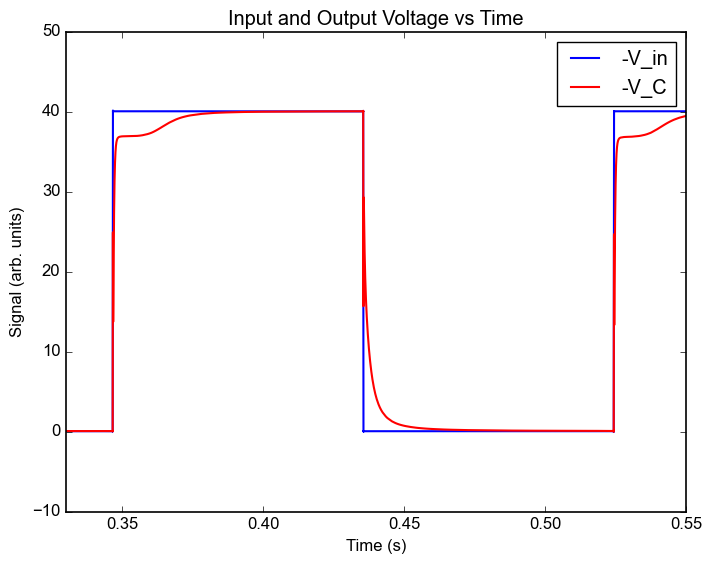

In [78]:
plt.plot(t, -V_in, label='-V_in', lw = 1.5, color = 'blue')
# plt.plot(t, V_R*10, label='V_R', lw = 1.5, color = 'green')
plt.plot(t, -V_C, label='-V_C', lw = 1.5, color = 'red')
# plt.plot(t, main_trigger, label='Main Trigger', lw = 1.5, color = 'red')
# plt.plot(t, second_trigger, label='Second Trigger', lw = 1.5, color = 'black')
plt.xlabel('Time (s)')
plt.ylabel('Signal (arb. units)')
plt.xlim(0.33, 0.55)
plt.ylim(-10, 50)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()

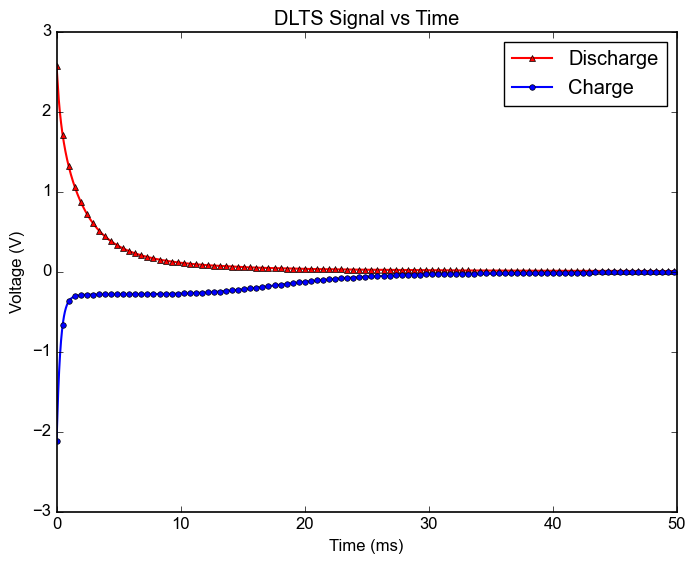

In [79]:
t = data2[:, 0]
V = data2[:, 2]
V2 = data2[:, 1]

plt.plot(t*1e3, V, label='Discharge', color='red', ls='-', lw = 1.5, marker='^', markersize=4, markevery=50)
plt.plot(t*1e3, V2, label='Charge', color='blue', ls='-', lw = 1.5, marker='o', markersize=4, markevery=50)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time')
plt.xlim(0.00, 50)
plt.ylim(-3, 3)
plt.legend(frameon=True, numpoints=1)
plt.show()


a = 0.615 ± 0.00331
b = 0.00621 ± 2.39e-05
R^2 = 0.974
-----------------------------
C (fitted) = (5.647 ± 0.022) nF


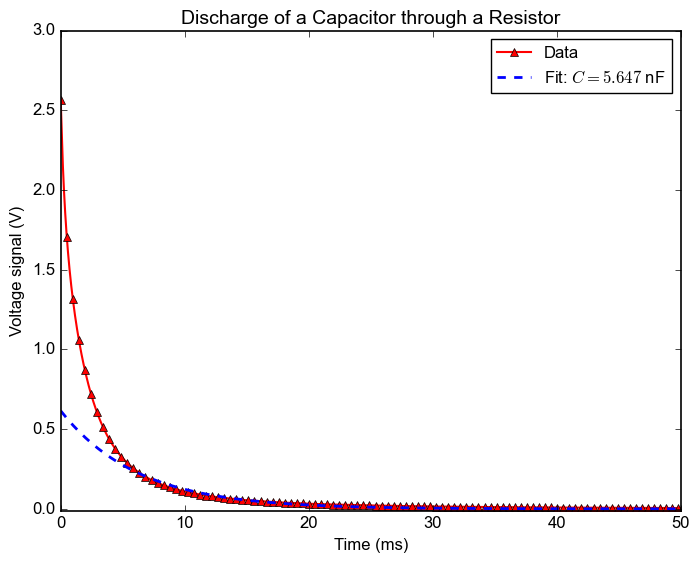

In [80]:
def func(x, a, b):
    return a * np.exp(-x / b)


mask = np.isfinite(t) & np.isfinite(V) & (t >= 0.005) & (t <= 0.05)
# Initial guesses: a ~ peak voltage in window, b ~ C_actual*(R1+R2) (time constant)
if np.any(mask):
    a0 = np.max(V[mask])
else:
    a0 = np.max(V)
C_actual = 3e-9  # 10 nF
b0 = C_actual * (R1 + R2)
p0 = [a0, b0]

popt, pcov = curve_fit(func, t[mask], V[mask], p0=p0, maxfev=10000)
sigma_fit = func(t[mask], *popt)
a, b= popt

# Coefficient of determination
ss_res = np.sum((V[mask] - sigma_fit) ** 2)
ss_tot = np.sum((V[mask] - np.mean(V[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr

C = b / (R1 + R2)
C_err = C * np.sqrt((b_err / b) ** 2)


print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = {r2:.3f}")
print("-----------------------------")
print(f"C (fitted) = ({C*1e9:.3f} ± {C_err*1e9:.3f}) nF")



x = np.linspace(0.00, 0.05, 100)
plt.plot(t*1e3, V, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=50)
plt.plot(x*1e3, func(x, *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 50)
plt.ylim(-0.01, 3)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

C:\Users\lugwi\AppData\Local\Temp\ipykernel_21492\2609870272.py:6: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 3)


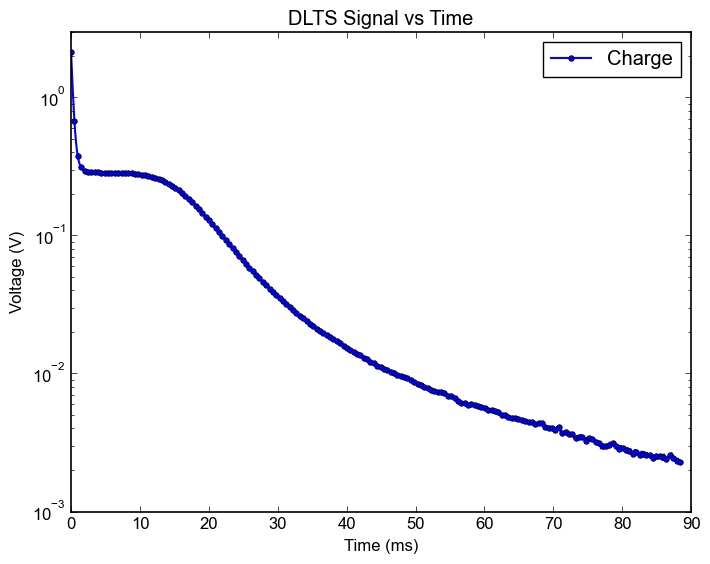

In [81]:

plt.semilogy(t*1e3, -V2, label='Charge', color='blue', ls='-', lw = 1.5, marker='o', markersize=4, markevery=50)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time')
plt.xlim(0.00, 90)
plt.ylim(0, 3)
plt.legend(frameon=True, numpoints=1)
plt.show()

a = 1.39 ± 0.00488
b = 0.00835 ± 1.25e-05
R^2 = 0.996
-----------------------------
C (fitted) = (7.593 ± 0.011) nF


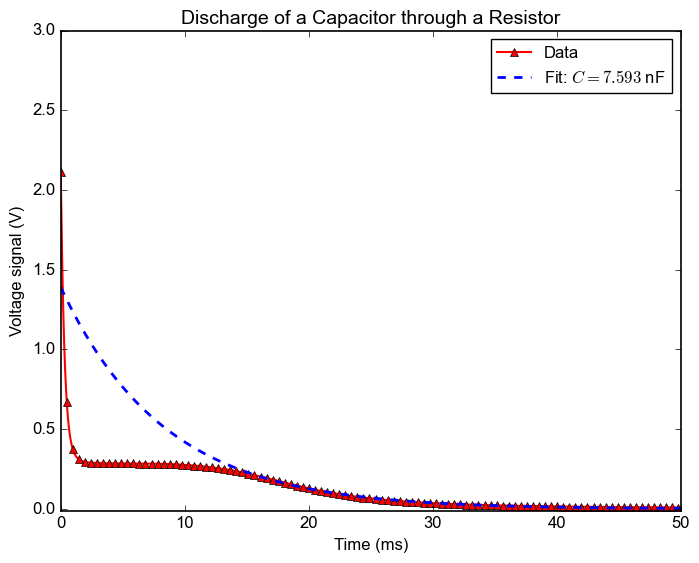

In [82]:
def func(x, a, b):
    return a * np.exp(-x/ b)


mask = np.isfinite(t) & np.isfinite(V2) & (t >= 0.015) & (t <= 0.05)
y = -V2

# Initial guesses: a ~ peak voltage in window, b ~ C_actual*(R1+R2) (time constant)
if np.any(mask):
    a0 = np.max(y[mask])
    c0 = np.min(y[mask])
else:
    a0 = np.max(y)
    c0 = np.min(y)
C_actual = 3e-9  # 10 nF
b0 = C_actual * (R1 + R2)
p0 = [a0, b0]

bounds = ([0.0, 1e-12], [np.inf, np.inf])
popt, pcov = curve_fit(func, t[mask], y[mask], p0=p0, bounds=bounds, max_nfev=20000)
sigma_fit = func(t[mask], *popt)
a, b= popt

# Coefficient of determination
ss_res = np.sum((y[mask] - sigma_fit) ** 2)
ss_tot = np.sum((y[mask] - np.mean(y[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr

C = b / (R1 + R2)
C_err = C * np.sqrt((b_err / b) ** 2)

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = {r2:.3f}")
print("-----------------------------")
print(f"C (fitted) = ({C*1e9:.3f} ± {C_err*1e9:.3f}) nF")


x = np.linspace(0.00, 0.05, 100)
plt.plot(t*1e3, -V2, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=50)
plt.plot(x*1e3, func(x, *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 50)
plt.ylim(-0.01, 3)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()